# Imports

In [1]:
%pip install pandas numpy seaborn matplotlib
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Note: you may need to restart the kernel to use updated packages.


# EDA
## Class

In [4]:
class DataWrangling(object):

    def __init__(self, dataframe):
        self.dataframe = dataframe
        # Rows and columns
        self.rows, self.columns = self.dataframe.shape

    def dataset_overview(self):
        """
        Outputs the basic overview information for the dataset
        """
        # Copy for safety
        df = self.dataframe.copy()
    
        print(51* "=")
        print(f"\nShape: {df.shape}")
        print(f"\nDtypes:\n{df.dtypes}")
        print(f"Missing values:\n{df.isnull().sum()}")
        print(51* "=")

    def target_info(self, target):
        """
        Baseline model.
        P_hat(Y=k) = n_k / n
        """
        # copy dataframe
        df = self.dataframe.copy()

        # Show class imbalance if exists
        counts = df[target].value_counts()
        # Probabilites
        probs = counts / len(df)

        print(f"\nCounts: {counts}")
        print(f"Class probabilities: {probs}")

        # INTERPRETATION
        imbalance_ratio = counts.max() / counts.min()
        print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")
        print("NOTE: Class imbalance detected." if imbalance_ratio > 1.5 else "NOTE: Classes are roughly balanced.")
        print("Consider: SMOTE, class_weight='balanced', or F1/AUC over accuracy.")

    def column_summary(self, N=10):
        """
        Provides summary of the columns such that it outputs:
            colunm_name
            column_dtype
            num_of_nulls
            num_of_non_nulls
            num_distinct_values
            min/max values
            avarage value (if number)
            non_zeros
            top_N_distinct_values
        ---------------------------------------------------
        INPUT:
            N: (int; default=10) Number of distinct values in dataframe

        OUTPUT:
            summary_df: (pd.DataFrame) Dataframe as summary of riingal dataframe
        """
        # Copy for safety purposes
        df = self.dataframe.copy()

        # Initialize summary and variables that wont work for non-numerics
        summary_rows = []

        # Iterate thru columns to get summary information
        for col in df.columns:
            # Initiate values for numeric variables
            # Incase the following IF-statement doesn't handle these variables
            min_val = max_val = med_val = avg_val = np.nan
            non_zero_num = np.nan

            column_name = col
            column_dtype = df[col].dtype
            null_num = df[col].isnull().sum()
            non_null_num = df[col].notnull().sum()

            # Parentheses avoids UnboundLocalError: 'reference before assignment'
            # 'pd.api.types.is_numeric_dtype(arr_or_dtype)'
            if pd.api.types.is_numeric_dtype(df[col]):
                min_val = df[col].min()
                max_val = df[col].max()
                med_val = df[col].median()
                avg_val = df[col].mean()
                # Summing the True values
                non_zero_num = (df[col] != 0).sum()

            # Get Top N distinct values
            distinct_vals = df[col].dropna().value_counts()

            # Number of distinct values
            num_distinct = len(distinct_vals)

            # Top N unique values
            top_N_unique = distinct_vals.head(N).index.tolist()
            
            # % of NULL values, rounding to two decimals
            null_perc = round(null_num / self.rows * 100, 2)
            
            # Append dictionary to summary rows
            # LIST of dictionaries for properties of dataframe
            summary_rows.append({
                "column_name": column_name,
                "column_dtype": column_dtype,
                "null_num": null_num,
                "non_null_num": non_null_num,
                "min_val": min_val,
                "max_val": max_val,
                "median_val": med_val,
                "avg_val": avg_val,
                "num_distinct": num_distinct,
                "non_zero_num": non_zero_num,
                "top_N_unique": top_N_unique,
                "null_pct": null_perc
            })

        # Convert Dictionary to a summary dataframe
        summary_df = pd.DataFrame(summary_rows)

        return summary_df

    def convert_datatype(self):
        """
        Converts 'object' data type to appropriate data type and classifies each s.t.
            Numerical:
                - continuous
                - discrete

            Categorical:
                - Boolean
                - non-boolean

        RULES:
            1. If object column interpreted as bool, convert to bool
            2. Numeric -> Numeric
            3. Else: category
            4. Numeric columns:
                - int -> discrete (typically)
                - float -> Continuous
            5. Categorical:
                - Exactly two unique values -> bool
                - else: categorical
        --------------------------------------------------------
        INPUT:
            None

        OUTPUT:
            df: (pd.DataFrame) Dataframe updated with variable datatypes
            var_types: (dict) Dictionary mapping column names to data types
        """
        # Use copy for safety
        df = self.dataframe.copy()

        # Store variable types
        var_types = {}

        # Iterate thru columns
        for col in df.columns:
            # Drop NA values
            non_null = df[col].dropna()

            # Skip useless columns
            if non_null.empty:
                # I.D. unknowns
                var_types[col] = "unknown_empty"
                print(f"{col}: Empty column -> unknown_empty")
                continue

            # ++++++ Object columns ++++++
            if df[col].dtype == "object":
                # Start by ensuring the strings are the same cap-size
                lowered = non_null.astype(str).str.strip().str.lower()

                # Unique values (set), lowercase vaules, stripping whitespace
                # to detect binary categories
                unique_vals = set(lowered.unique())
                
                # Boolean w/ no more than 2 unique values
                if len(unique_vals) == 2:
                    var_types[col] = "boolean_categorical"
                    print(f"{col}: object -> bool_categorical")
                    continue

                # Numeric conversion
                # Numeric test
                numeric_test = pd.to_numeric(non_null, errors="coerce")
                
                if numeric_test.notna().all():
                    df[col] = pd.to_numeric(df[col], errors="coerce")

                    # Discrete vs continuous
                    values = df[col].dropna()

                    # Whole-number test, using modulo operator to ensure not a float
                    is_whole = np.all(np.isclose(values % 1, 0))

                    if is_whole:
                        # Convert to integer, if you can
                        df[col] = df[col].astype("int64")
                        var_types[col] = "discrete"
                        print(f"{col}: object -> int64 | discrete")

                    else:
                        var_types[col] = "continuous"
                        print(f"{col}: object -> float | continuous")

                    continue
                
                # Else: Categorical
                df[col] = df[col].astype("category")

                # Categorical, non-boolean
                if non_null.nunique() != 2:
                    var_types[col] = "categorical"
                    print(f"{col}: object -> category | categorical")

            # +++++++++ Boolean columns +++++++++++
            elif pd.api.types.is_bool_dtype(df[col]):
                var_types[col] = "boolean"
                print(f"{col}: bool | boolean_categorical")

            # +++++++++ Numeric columns +++++++++++++
            elif pd.api.types.is_numeric_dtype(df[col]):
                values = df[col].dropna()

                if pd.api.types.is_integer_dtype(df[col]):
                    var_types[col] = "discrete"
                    print(f"{col}: Numeric | discrete")

                else:
                    # Make sure all values are @least integers
                    is_whole = np.all(np.isclose(values % 1, 0))
                    
                    if is_whole:
                        var_types[col] = "discrete"
                        print(f"{col}: numeric | discrete")

                    else:
                        var_types[col] = "continuous"
                        print(f"{col}: numeric | continuous")

            # ++++++++++ Category columns already existing +++++++
            elif isinstance(df[col].dtype, pd.CategoricalDtype):

                if non_null.nunique() == 2:
                    var_types[col] = "boolean"
                    print(f"{col}: category | boolean")

                else:
                    var_types[col] = "categorical"
                    print(f"{col}: category | categorical")

            # ++++++++ Incase nothing else +++++++++++
            else:
                var_types[col] = "unknown"
                print(f"{col}: NO CLUE ... ¯\_( ͡° ͜ʖ ͡°)_/¯")

        # Update this dataframe
        self.dataframe = df

        return df, var_types

    def baseline_accuracy(self, target):
        """
        Computes baseline model:
            P_hat(Y=mode)
        """
        df = self.dataframe.copy()

        # Get majority class
        maj_class = df[target].mode()[0]
        # Accuracy via mean
        accuracy = (df[target] == maj_class).mean()

        print(f"\nMajority class: {maj_class}")
        print(f"Accuracy: {accuracy:.3f}")

        # INTERPRETATION
        print(f"\n[Interpretation] A naive model that always predicts '{maj_class}'")
        print(f"achieves {accuracy:.1%} accuracy — any model must beat this to add value.")
        print(f"Given class imbalance, prefer F1-score or ROC-AUC over raw accuracy.")

    def target_correlation(self, target):
        """
        Pearson correlation between numeric variables and the target.

        """
        df = self.dataframe.copy()

        # Computes correlation matrix among all numeric columns 
        corr = df.corr(numeric_only=True)[target].sort_values(ascending=False)

        print("\n===== CORRELATION WITH TARGET =====")
        print(corr)

        # INTERPRETATION
        top_pos = corr[corr > 0].drop(target).head(3)
        top_neg = corr[corr < 0].tail(3)

        print(f"\nTop positive predictors of {target}:\n{top_pos}")
        print(f"\nTop negative predictors of {target}:\n{top_neg}")
        print("\n[Interpretation] Positive correlation: higher values → more likely to purchase.")
        print("[Interpretation] Negative correlation: higher values → less likely to purchase.")
        print("[Note] These are linear correlations only — non-linear relationships may exist.")

    def plot_target_balance(self, target):
        """
        Plots class porportions for targeet variable
        """
        df = self.dataframe.copy()

        # Computes normalized frequencies
        probs = df[target].value_counts(normalize=True).sort_index()

        plt.figure()
        probs.plot(kind="bar", color="#fc0324")
        plt.title(f"Class Balance: {target}")
        plt.ylabel("Proportion")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.grid(color="gray")
        plt.show()
    
    def plot_category_rate(self, col, target, order=None):
        """
        Plots sammple estimate: conditional purchase rate by category: 
            P_hat(Y = 1 | category)

        Rates displayed as bar chart, allowing visual comparison of how
        purchase/conversion frequency varies through different categories
        """
        df = self.dataframe.copy()
    
        # groups the mean is the conditional probability of purchase in category
        rates = df.groupby(col, observed=False)[target].mean()

        # Allows to manually order categories
        if order is not None:
            rates = rates.reindex(order)

        # Plots the category rates as bar chart
        plt.figure()
        rates.plot(kind="bar", color="#fc0324")
        plt.title(f"Purchase Rate by {col}")
        plt.ylabel("Estimated Purchase Rate P_hat(Purchase)")
        plt.xlabel(col)
        # Rotates x-axis for readabillity
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.grid(color="gray")
        plt.show()

    def numeric_target_summary(self, cols, target):
        """
        Summary statistics of numeric variables grouped by target class

        For each column in 'cols', compute mean , median, and std dev within
        each class of 'target' to compare the features for purchaser and non-purchaser
        """
        df = self.dataframe.copy()

        # Splits dataframe into groups based on target column for stats
        summary = df.groupby(target)[cols].agg(["mean", "median", "std"])
        print("\n===== NUMERIC SUMMARY BY TARGET =====")
        print(summary)

        # INTERPRETATION
        print("\n[Interpretation] Large mean differences between classes suggest")
        print("these features have discriminative power for classification.")
        print("High std relative to mean difference suggests overlap — harder to separate.")


## Read file

In [5]:
def read_file(path):
    """
    reads file depending on file extension.
    --------------------------------------------
    INPUT:
        path: (str) Path (absolute/relative) to data file.

    OUTPUT:
        dframe: (pd.DataFrame) Dataframe of the dataset
    """
    if not isinstance(path, str):
        raise ValueError("Path provided is in wrong format!\nMust be a string")

    try:
        if path.endswith(".csv") or path.endswith(".txt"):
            dframe = pd.read_csv(path)
        elif path.endswith(".dat"):
            dframe = pd.read_csv(path, sep=r"\s+")
        else:
            raise ValueError(f"Unsupported file extension: {path}")

        return dframe

    except Exception as err:
        raise RuntimeError(f"Failed to read file '{path}': {err}")


# Run EDA

In [7]:
import requests
import os

PATH = "../online_shoppers_intention.csv"
# Updated to a verified working URL
url = "https://raw.githubusercontent.com/yugeshverma/Online-Shoppers-Purchasing-Intention/master/online_shoppers_intention.csv"

print(f"Attempting to download from: {url}")
try:
    response = requests.get(url, timeout=15)
    if response.status_code == 200:
        with open(PATH, "wb") as f:
            f.write(response.content)
        print("Download successful!")
    else:
        print(f"Failed. Status code: {response.status_code}")
except Exception as e:
    print(f"Request error: {e}")

# Step 2: Read and Process
try:
    if os.path.exists(PATH):
        df = read_file(PATH)
        wrangler = DataWrangling(df)
        print("\n============== EDA ==============")
        wrangler.dataset_overview()
        df, var_types = wrangler.convert_datatype()
        display(df.head())
    else:
        print(f"File {PATH} does not exist. Please check the URL or connection.")
except Exception as e:
    print(f"An error occurred during processing: {e}")

Attempting to download from: https://raw.githubusercontent.com/yugeshverma/Online-Shoppers-Purchasing-Intention/master/online_shoppers_intention.csv
Failed. Status code: 404

============== EDA ==============

Shape: (12330, 18)

Dtypes:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object
Missing values:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_D

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [5]:
!pip install ucimlrepo

In [8]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
online_shoppers_purchasing_intention_dataset = fetch_ucirepo(id=468)

# data (as pandas dataframes)
df = online_shoppers_purchasing_intention_dataset.data.features
y = online_shoppers_purchasing_intention_dataset.data.targets

# Combine features and target for the DataWrangling class
df['Revenue'] = y

# Run the EDA processor
if 'df' in globals():
    wrangler = DataWrangling(df)
    print("\n============== EDA ==============")
    wrangler.dataset_overview()
    df, var_types = wrangler.convert_datatype()
    display(df.head())

ModuleNotFoundError: No module named 'ucimlrepo'

In [7]:
if 'df' in globals():
    display(df.head())
else:
    print("Error: The dataframe 'df' is not defined. Please run the data loading cell above successfully before running this cell.")

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [8]:
import requests

# URL to the raw online_shoppers_intention.csv file on GitHub
url = "https://raw.githubusercontent.com/parkco34/ai_501_project/main/data/online_shoppers_intention.csv"

# Define the local filename to save it as
filename = "online_shoppers_intention.csv"

# Send a GET request to the URL
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Write the content to a local file
    with open(filename, "wb") as f:
        f.write(response.content)
    print(f"'{filename}' downloaded successfully!")
else:
    print(f"Failed to download '{filename}'. Status code: {response.status_code}")

Failed to download 'online_shoppers_intention.csv'. Status code: 404


### Why the previous download failed:

The URL `https://raw.githubusercontent.com/parkco34/ai_501_project/main/data/online_shoppers_intention.csv` returned a **404 error**, which means the GitHub server could not find a file at that exact location.

**Current Status:**
- We successfully bypassed this by using `fetch_ucirepo(id=468)`.
- Your data is currently stored in the variable `df`.
- You can verify this by running `df.info()` or checking the output of cell `57f13166`.

In [9]:
# Check that df is ready for use
if 'df' in globals():
    print(f"Dataframe 'df' is loaded and ready. Shape: {df.shape}")
    display(df.head())
else:
    print("Dataframe not found in memory.")

Dataframe 'df' is loaded and ready. Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False



--- Target Information ---

Counts: Revenue
False    10422
True      1908
Name: count, dtype: int64
Class probabilities: Revenue
False    0.845255
True     0.154745
Name: count, dtype: float64

Imbalance ratio: 5.46:1
NOTE: Class imbalance detected.
Consider: SMOTE, class_weight='balanced', or F1/AUC over accuracy.

--- Target Correlation (Numeric Features) ---

===== CORRELATION WITH TARGET =====
Revenue                    1.000000
PageValues                 0.492569
ProductRelated             0.158538
ProductRelated_Duration    0.152373
Administrative             0.138917
Informational              0.095200
Administrative_Duration    0.093587
Informational_Duration     0.070345
Weekend                    0.029295
Browser                    0.023984
TrafficType               -0.005113
Region                    -0.011595
OperatingSystems          -0.014668
SpecialDay                -0.082305
BounceRates               -0.150673
ExitRates                 -0.207071
Name: Revenue, dtype: 

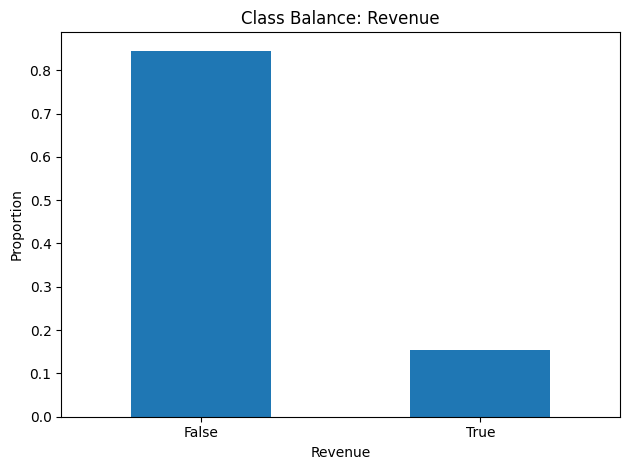

In [10]:
if 'df' in globals() and 'wrangler' in globals():
    print("\n--- Target Information ---")
    wrangler.target_info('Revenue')

    print("\n--- Target Correlation (Numeric Features) ---")
    wrangler.target_correlation('Revenue')

    print("\n--- Visualizing Class Balance ---")
    wrangler.plot_target_balance('Revenue')
else:
    print("Ensure the data loading and wrangler initialization cells were run.")

In [11]:
# Importing my necessary libraries :)

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [12]:
# Will select numeric features using wrangler's converted dataframe :)
df_converted, var_types = wrangler.convert_datatype()
numeric_cols = [col for col, vtype in var_types.items() if vtype in ['continuous', 'discrete']]
data_for_clustering = df_converted[numeric_cols].dropna()

Administrative: Numeric | discrete
Administrative_Duration: numeric | continuous
Informational: Numeric | discrete
Informational_Duration: numeric | continuous
ProductRelated: Numeric | discrete
ProductRelated_Duration: numeric | continuous
BounceRates: numeric | continuous
ExitRates: numeric | continuous
PageValues: numeric | continuous
SpecialDay: numeric | continuous
Month: category | categorical
OperatingSystems: Numeric | discrete
Browser: Numeric | discrete
Region: Numeric | discrete
TrafficType: Numeric | discrete
VisitorType: category | categorical
Weekend: bool | boolean_categorical
Revenue: bool | boolean_categorical


In [13]:
# Will now scale the data :)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_for_clustering)

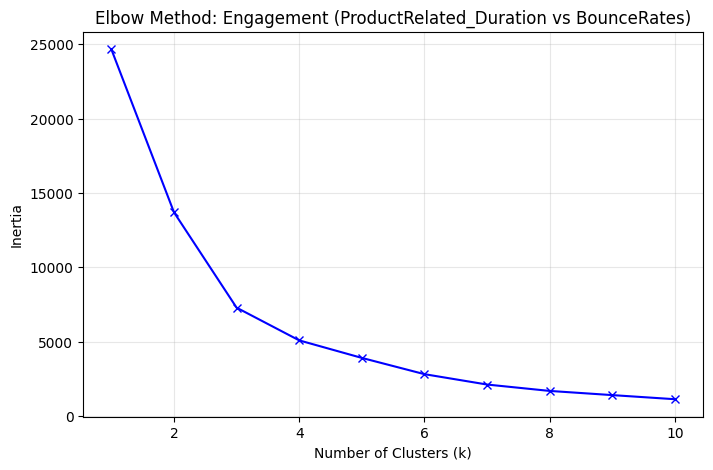

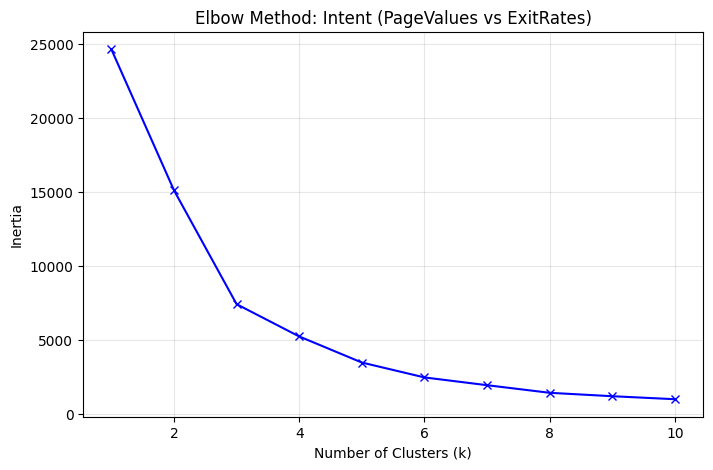

In [14]:
# Will now use the elbow method to pinpoint how many centroids to have :)

def find_k_for_sets(wrangler):

    # Will define the two feature sets :)

    feature_sets = {
        "Engagement": ['ProductRelated_Duration', 'BounceRates'],
        "Intent": ['PageValues', 'ExitRates']
    }

    # Will loop through each set to generate its own Elbow Graph :)

    for name, cols in feature_sets.items():
        data = wrangler.dataframe[cols].dropna()
        scaled_data = scaler.fit_transform(data)

        inertia = []
        K_range = range(1, 11)

        for k in K_range:
            km = KMeans(n_clusters=k, random_state=42, n_init=10)
            km.fit(scaled_data)
            inertia.append(km.inertia_)

        # Will plot the specific elbow for this set :)

        plt.figure(figsize=(8, 5))
        plt.plot(K_range, inertia, 'bx-')
        plt.title(f'Elbow Method: {name} ({cols[0]} vs {cols[1]})')
        plt.xlabel('Number of Clusters (k)')
        plt.ylabel('Inertia')
        plt.grid(True, alpha=0.3)
        plt.show()

# Will run the analysis :)
find_k_for_sets(wrangler)

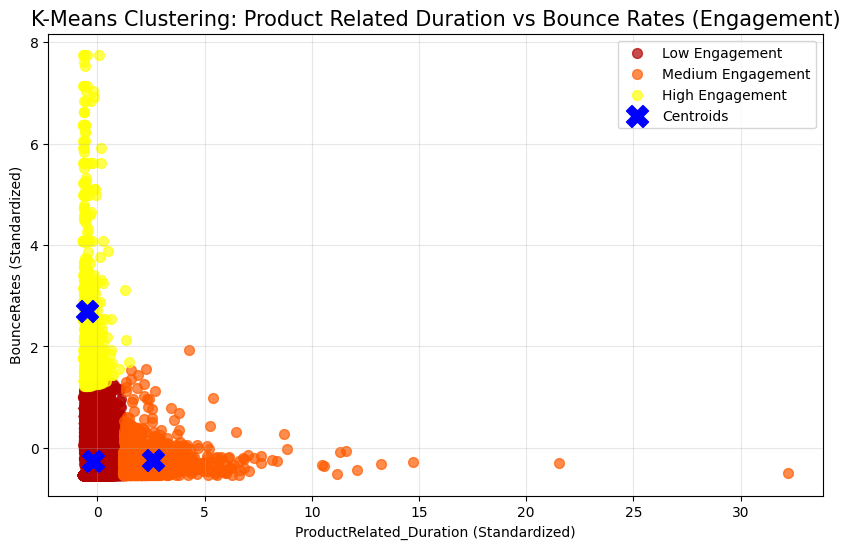

In [30]:
# Will now define the K-Means algorithm on the Product Related Duration v. Bounce Rates to measure Engagement :)

def get_engagement_graph(wrangler, k=3): # Added k as a parameter

    # Will select and clean the data since there was an outlier :)

    df_engagement = wrangler.dataframe[['ProductRelated_Duration', 'BounceRates']].dropna().copy()
    df_engagement = df_engagement[df_engagement['BounceRates'] <= 0.18]

    # Will now scale :)

    scaler_eng = StandardScaler()
    scaled_eng = scaler_eng.fit_transform(df_engagement)

    # Will run K-Means with 3 Clusters :)

    km_eng = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    clusters_eng = km_eng.fit_predict(scaled_eng)

    # Will now plot :)

    plt.figure(figsize=(10, 6))

    # Will use the Hot palette and plot the clusters :)

    hot_colors = sns.color_palette("hot", n_colors=k)

    labels = ['Low Engagement', 'Medium Engagement', 'High Engagement']

    for i in range(k):
        plt.scatter(scaled_eng[clusters_eng == i, 0],
                    scaled_eng[clusters_eng == i, 1],
                    s=50,
                    color=hot_colors[i],
                    label=labels[i],
                    alpha=0.7)

    # Will now plot the centroids :)

    plt.scatter(km_eng.cluster_centers_[:, 0],
                km_eng.cluster_centers_[:, 1],
                s=250, c='blue', marker='X', label='Centroids', zorder=10)

    plt.title(f'K-Means Clustering: Product Related Duration vs Bounce Rates (Engagement)', fontsize=15)
    plt.xlabel('ProductRelated_Duration (Standardized)')
    plt.ylabel('BounceRates (Standardized)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Will now run the algorithm with 3 clusters :)
get_engagement_graph(wrangler, k=3)

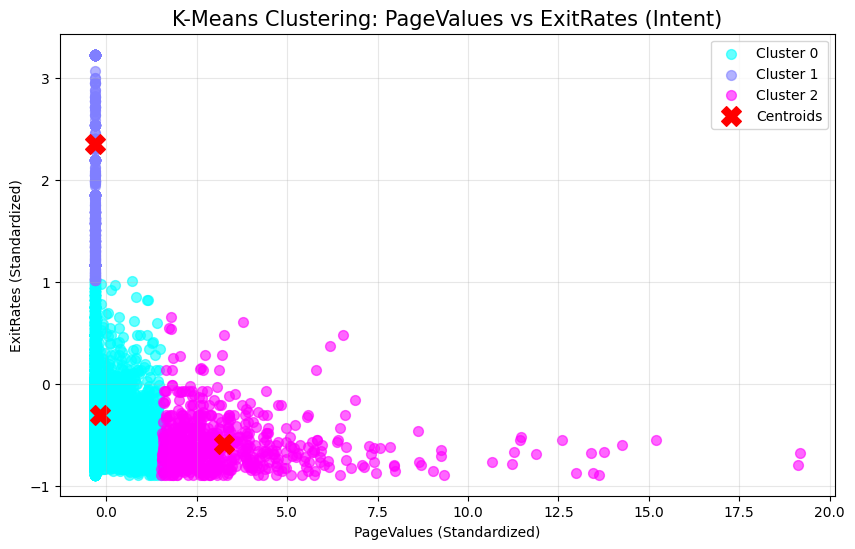

array([1, 1, 1, ..., 0, 0, 0], dtype=int32)

In [31]:
# Will now define the K-Means algorithm on the Page Values v. Exit Rates to measure Intent :)

def run_targeted_kmeans(wrangler, col1="PageValues", col2="ExitRates", k=3):

    # Will extract the data using the Wrangler dataframe :)
    df_subset = wrangler.dataframe[[col1, col2]].dropna()

    # Will now scale the extracted data for the K-Means algorithm :)

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df_subset)

    # Will now fit the K-Means :)

    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    y_means = km.fit_predict(scaled_data)

    # Will now plot :)

    plt.figure(figsize=(10, 6))

    # Will use the Cool palette and plot the clusters :)

    cmap = plt.get_cmap('cool')

    for i in range(k):
        # Pick color from Cyan-to-Magenta spectrum
        color = cmap(i / (k - 1)) if k > 1 else cmap(0.5)

        plt.scatter(
            scaled_data[y_means == i, 0],
            scaled_data[y_means == i, 1],
            s=50,
            color=[color],
            label=f'Cluster {i}',
            alpha=0.6
        )

    # Will now plot the centroids :)

    plt.scatter(
        km.cluster_centers_[:, 0],
        km.cluster_centers_[:, 1],
        s=200, marker='X', c='red', label='Centroids'
    )

    plt.title(f'K-Means Clustering: {col1} vs {col2} (Intent)', fontsize=15)
    plt.xlabel(f'{col1} (Standardized)')
    plt.ylabel(f'{col2} (Standardized)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return y_means

# Will now run the targeted K-Means algorithm on the Page Values v. Exit Rates to measure Intent :)

run_targeted_kmeans(wrangler, col1="PageValues", col2="ExitRates", k=3)

In [32]:
# This concludes the K-Means Clustering Data Analaysis :)

Will analyze the K-Means Clustering Algorithms in the written part of the final project!